In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
user_profile = pd.read_csv('../../DATA/user_profile_preprocessed.csv', encoding='utf-8-sig')
event_log    = pd.read_csv('../../DATA/event_log_preprocessed.csv', encoding='utf-8-sig')

user_profile['가입일자'] = pd.to_datetime(user_profile['가입일자'])
user_profile['가입일']   = pd.to_datetime(user_profile['가입일'])
event_log['Event_Time']  = pd.to_datetime(event_log['Event_Time'])
event_log['Event_Date']  = pd.to_datetime(event_log['Event_Date'])

print("user_profile:", user_profile.shape)
print("event_log   :", event_log.shape)

user_profile: (12500, 10)
event_log   : (1757262, 11)


In [ ]:
LOG_ISSUE_START = pd.Timestamp('2025-03-10')
LOG_ISSUE_END   = pd.Timestamp('2025-03-14')
RETENTION_DAYS  = {'D0': 0, 'D3': 3, 'D7': 7, 'D30': 30}

# 활성 이벤트 (앱실행만)
active_event = event_log[event_log['Event_Type'] == '앱실행'].copy()
active_event['event_date'] = active_event['Event_Time'].dt.normalize()

# (User_ID, 날짜) 쌍으로 set 생성 
active_set = set(zip(active_event['User_ID'], active_event['event_date']))

print("활성 이벤트 수:", active_event.shape[0])
print("활성 유저 수  :", active_event['User_ID'].nunique())

활성 이벤트 수: 728657
활성 유저 수  : 12447


In [5]:
retention_df = user_profile[['User_ID', '가입일자', '가입일']].copy()
retention_df['가입월'] = retention_df['가입일자'].dt.month

for label, day in RETENTION_DAYS.items():

    target_date = retention_df['가입일'] + pd.Timedelta(days=day)
    retention_df[f'{label}_target_date'] = target_date

    # 잔존 여부 판정
    retention_df[f'{label}_retained'] = [
        1 if (uid, tdate) in active_set else 0
        for uid, tdate in zip(retention_df['User_ID'], target_date)
    ]

    # 장애 기간 플래그
    retention_df[f'{label}_is_log_issue'] = (
        (target_date >= LOG_ISSUE_START) &
        (target_date <= LOG_ISSUE_END)
    )

print("리텐션 판정 완료")
display(retention_df.head())

리텐션 판정 완료


,User_ID,가입일자,가입일,가입월,D0_target_date,D0_retained,D0_is_log_issue,D3_target_date,D3_retained,D3_is_log_issue,D7_target_date,D7_retained,D7_is_log_issue,D30_target_date,D30_retained,D30_is_log_issue
0,U0000001,2025-01-25,2025-01-25,1,2025-01-25,1,False,2025-01-28,1,False,2025-02-01,1,False,2025-02-24,1,False
1,U0000002,2025-05-06,2025-05-06,5,2025-05-06,1,False,2025-05-09,1,False,2025-05-13,1,False,2025-06-05,0,False
2,U0000003,2025-05-14,2025-05-14,5,2025-05-14,1,False,2025-05-17,0,False,2025-05-21,0,False,2025-06-13,0,False
3,U0000004,2025-02-23,2025-02-23,2,2025-02-23,1,False,2025-02-26,1,False,2025-03-02,0,False,2025-03-25,1,False
4,U0000005,2025-02-18,2025-02-18,2,2025-02-18,1,False,2025-02-21,1,False,2025-02-25,1,False,2025-03-20,1,False


In [6]:
# 전체 리텐션율 (장애 포함 vs 제외)
print(f"{'':5} {'전체포함':>10} {'장애제외':>10} {'장애유저수':>10}")
print("-" * 42)

for label in RETENTION_DAYS.keys():
    rate_all   = retention_df[f'{label}_retained'].mean() * 100
    clean_mask = ~retention_df[f'{label}_is_log_issue']
    rate_clean = retention_df[clean_mask][f'{label}_retained'].mean() * 100
    issue_cnt  = retention_df[f'{label}_is_log_issue'].sum()
    print(f"{label:5} {rate_all:>9.1f}% {rate_clean:>9.1f}% {issue_cnt:>10}명")

            전체포함       장애제외      장애유저수
------------------------------------------
D0         98.0%      99.8%        341명
D3         71.7%      73.1%        341명
D7         42.2%      43.1%        368명
D30        24.3%      25.1%        771명


In [7]:
# 코호트별 리텐션율 테이블
cohort_result = retention_df.groupby('가입월').agg(
    전체유저=('User_ID', 'count')
).reset_index()

for label in RETENTION_DAYS.keys():
    tmp = retention_df.groupby('가입월')[f'{label}_retained'].sum().reset_index()
    tmp.columns = ['가입월', f'{label}_잔존수']
    cohort_result = cohort_result.merge(tmp, on='가입월', how='left')
    cohort_result[f'{label}(%)'] = round(
        cohort_result[f'{label}_잔존수'] / cohort_result['전체유저'] * 100, 1
    )

display_cols = ['가입월', '전체유저', 'D0(%)', 'D3(%)', 'D7(%)', 'D30(%)']
display(cohort_result[display_cols])

,가입월,전체유저,D0(%),D3(%),D7(%),D30(%)
0,1,2124,99.8,70.6,40.0,22.6
1,2,4384,99.8,76.3,47.0,29.0
2,3,2122,88.8,64.7,36.7,23.0
3,4,2082,99.9,70.2,40.3,20.7
4,5,1788,99.9,72.3,41.9,20.4


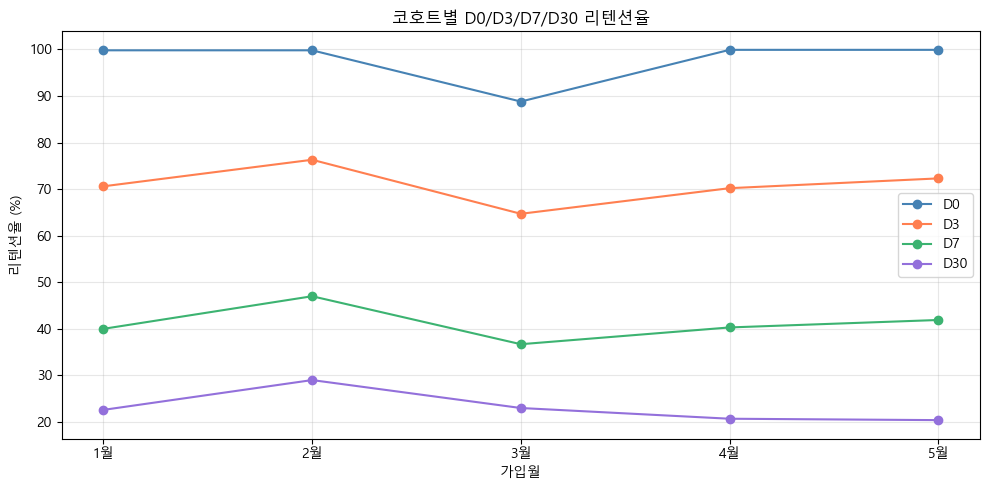

In [9]:
# 라인차트
rate_cols = ['D0(%)', 'D3(%)', 'D7(%)', 'D30(%)']
colors    = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']

plt.figure(figsize=(10, 5))
for col, color in zip(rate_cols, colors):
    plt.plot(
        cohort_result['가입월'].astype(str) + '월',
        cohort_result[col],
        marker='o', label=col.replace('(%)', ''),
        color=color
    )

plt.title('코호트별 D0/D3/D7/D30 리텐션율')
plt.xlabel('가입월')
plt.ylabel('리텐션율 (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

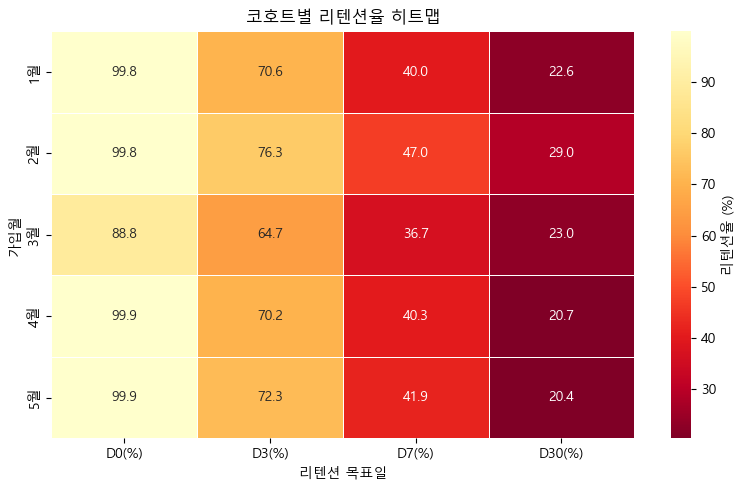

In [10]:
# 히트맵
heatmap_data = cohort_result.set_index('가입월')[rate_cols].copy()
heatmap_data.index = heatmap_data.index.astype(str) + '월'

plt.figure(figsize=(8, 5))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd_r',
    linewidths=0.5,
    cbar_kws={'label': '리텐션율 (%)'}
)
plt.title('코호트별 리텐션율 히트맵')
plt.xlabel('리텐션 목표일')
plt.ylabel('가입월')
plt.tight_layout()
plt.show()

[ 단계별 평균 이탈률 ]
D0         : 98.0%
D0 -> D3   : 26.2%p 이탈
D3 -> D7   : 29.5%p 이탈
D7 -> D30  : 17.9%p 이탈


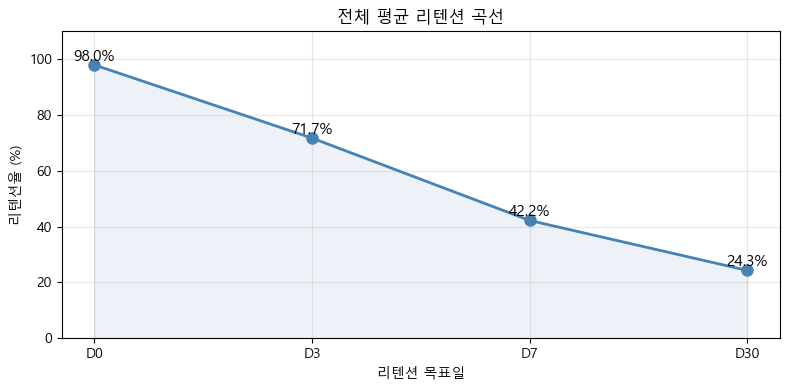

In [11]:
# 전체 평균 리텐션 곡선
rates  = {label: retention_df[f'{label}_retained'].mean() * 100 for label in RETENTION_DAYS}
labels = list(rates.keys())
values = list(rates.values())

print("[ 단계별 평균 이탈률 ]")
print(f"D0         : {rates['D0']:.1f}%")
print(f"D0 -> D3   : {rates['D0']  - rates['D3']:.1f}%p 이탈")
print(f"D3 -> D7   : {rates['D3']  - rates['D7']:.1f}%p 이탈")
print(f"D7 -> D30  : {rates['D7']  - rates['D30']:.1f}%p 이탈")

plt.figure(figsize=(8, 4))
plt.plot(labels, values, marker='o', color='steelblue', linewidth=2, markersize=8)
plt.fill_between(labels, values, alpha=0.1, color='steelblue')
for i, (l, v) in enumerate(zip(labels, values)):
    plt.text(i, v + 1.5, f'{v:.1f}%', ha='center', fontsize=11)
plt.title('전체 평균 리텐션 곡선')
plt.xlabel('리텐션 목표일')
plt.ylabel('리텐션율 (%)')
plt.ylim(0, 110)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# 주의 코호트 장애 영향 확인 (2월 D30, 3월 D0/D3/D7)
caution_cases = [(2, 'D30'), (3, 'D0'), (3, 'D3'), (3, 'D7')]

print(f"{'코호트':>8} {'전체':>6} {'장애영향':>8} {'포함':>8} {'제외':>8}")
print("-" * 45)

for month, label in caution_cases:
    mask_cohort = retention_df['가입월'] == month
    mask_issue  = retention_df[f'{label}_is_log_issue']

    total      = mask_cohort.sum()
    issue_cnt  = (mask_cohort & mask_issue).sum()
    rate_all   = retention_df[mask_cohort][f'{label}_retained'].mean() * 100
    rate_clean = retention_df[mask_cohort & ~mask_issue][f'{label}_retained'].mean() * 100

    print(f"{month}월 {label:>4} {total:>6}명 {issue_cnt:>7}명 {rate_all:>7.1f}% {rate_clean:>7.1f}%")

     코호트     전체     장애영향       포함       제외
---------------------------------------------
2월  D30   4384명     771명    29.0%    32.6%
3월   D0   2122명     341명    88.8%    99.7%
3월   D3   2122명     341명    64.7%    72.3%
3월   D7   2122명     368명    36.7%    41.8%


In [13]:
# D0 미달성 유저 확인
d0_fail = retention_df[retention_df['D0_retained'] == 0]
print("D0 미달성 유저 수:", len(d0_fail))
print()
print("[ 가입경로별 분포 ]")
print(d0_fail.merge(user_profile[['User_ID', '가입경로']], on='User_ID')['가입경로'].value_counts())
print()
print("[ 가입월별 분포 ]")
print(d0_fail['가입월'].value_counts().sort_index())

D0 미달성 유저 수: 253

[ 가입경로별 분포 ]
가입경로
퍼포먼스광고    151
오가닉        98
Name: count, dtype: int64

[ 가입월별 분포 ]
가입월
1      4
2      9
3    237
4      2
5      1
Name: count, dtype: int64


In [15]:
# 5월 D30 목표일 확인
may_users = retention_df[retention_df['가입월'] == 5]
print("5월 가입자 D30 목표일 범위")
print("최솟값:", may_users['D30_target_date'].min())
print("최댓값:", may_users['D30_target_date'].max())

# 실제 이벤트 로그 마지막 날짜
print("\n이벤트 로그 마지막 날짜:", event_log['Event_Time'].max())

5월 가입자 D30 목표일 범위
최솟값: 2025-05-31 00:00:00
최댓값: 2025-06-25 00:00:00

이벤트 로그 마지막 날짜: 2025-06-30 22:59:51


In [16]:
retention_with_profile = retention_df.merge(
    user_profile[['User_ID', '가입경로', '기기', '알림수신동의여부']],
    on='User_ID', how='left'
)

for col in ['가입경로', '기기', '알림수신동의여부']:
    print(f"[ {col}별 D30 리텐션 ]")
    result = retention_with_profile.groupby(col)['D30_retained'].mean() * 100
    print(result.round(1))
    print()

[ 가입경로별 D30 리텐션 ]
가입경로
오가닉       24.3
퍼포먼스광고    24.3
Name: D30_retained, dtype: float64

[ 기기별 D30 리텐션 ]
기기
Android    24.5
iOS        24.1
Name: D30_retained, dtype: float64

[ 알림수신동의여부별 D30 리텐션 ]
알림수신동의여부
False    25.5
True     23.6
Name: D30_retained, dtype: float64



In [18]:
# 2월 가입자의 가입경로 분포
feb_users = user_profile[user_profile['가입일자'].dt.month == 2]
print("[ 2월 가입경로 분포 ]")
print(feb_users['가입경로'].value_counts())
print()

# 전체 가입경로 분포와 비교
print("[ 전체 가입경로 분포 ]")
print(user_profile['가입경로'].value_counts())

[ 2월 가입경로 분포 ]
가입경로
퍼포먼스광고    2390
오가닉       1943
Name: count, dtype: int64

[ 전체 가입경로 분포 ]
가입경로
퍼포먼스광고    6852
오가닉       5511
Name: count, dtype: int64


In [19]:
# 2월 리텐션이 높은 이유 추가 탐색

# 2월 가입자 행동 패턴
feb_event = event_log[
    event_log['User_ID'].isin(
        user_profile[user_profile['가입일자'].dt.month == 2]['User_ID']
    )
]

# 2월 vs 전체 챌린지 참여율 비교
total_users = user_profile['User_ID'].nunique()
feb_users_count = user_profile[user_profile['가입일자'].dt.month == 2]['User_ID'].nunique()

challenge_total = event_log[event_log['Event_Type'] == '챌린지참여']['User_ID'].nunique()
challenge_feb   = feb_event[feb_event['Event_Type'] == '챌린지참여']['User_ID'].nunique()

print(f"전체 챌린지 참여율: {challenge_total / total_users * 100:.1f}%")
print(f"2월  챌린지 참여율: {challenge_feb / feb_users_count * 100:.1f}%")

# 2월 온보딩 완료율
onboarding_total = event_log[event_log['Event_Type'] == '온보딩_완료']['User_ID'].nunique()
onboarding_feb   = feb_event[feb_event['Event_Type'] == '온보딩_완료']['User_ID'].nunique()

print(f"\n전체 온보딩 완료율: {onboarding_total / total_users * 100:.1f}%")
print(f"2월  온보딩 완료율: {onboarding_feb / feb_users_count * 100:.1f}%")

전체 챌린지 참여율: 75.0%
2월  챌린지 참여율: 76.0%

전체 온보딩 완료율: 45.8%
2월  온보딩 완료율: 46.6%


In [20]:
# 2월 가입자의 첫 7일 행동량 비교
event_with_month = event_log.merge(
    user_profile[['User_ID', '가입일자']],
    on='User_ID', how='left'
)
event_with_month['가입후일수'] = (
    event_with_month['Event_Time'].dt.normalize() -
    event_with_month['가입일자'].dt.normalize()
).dt.days
event_with_month['가입월'] = event_with_month['가입일자'].dt.month

first7 = event_with_month[event_with_month['가입후일수'].between(0, 6)]

print("[ 월별 첫 7일 평균 이벤트 수 ]")
print(first7.groupby('가입월')['Event_Type'].count() /
      user_profile.groupby(user_profile['가입일자'].dt.month)['User_ID'].count())

[ 월별 첫 7일 평균 이벤트 수 ]
가입월
1    39.376648
2    42.272354
3    34.594722
4    38.936599
5    39.337248
dtype: float64


In [21]:
# 첫 7일 이벤트 수와 D30 리텐션 상관관계
first7_count = event_with_month[
    event_with_month['가입후일수'].between(0, 6)
].groupby('User_ID').size().reset_index(name='첫7일_이벤트수')

retention_with_activity = retention_df.merge(
    first7_count, on='User_ID', how='left'
).fillna(0)

# 구간별로 나눠서 D30 리텐션 비교
retention_with_activity['활동구간'] = pd.cut(
    retention_with_activity['첫7일_이벤트수'],
    bins=[0, 10, 30, 60, 100, 9999],
    labels=['0~10개', '11~30개', '31~60개', '61~100개', '100개+']
)

result = retention_with_activity.groupby('활동구간', observed=True).agg(
    유저수=('User_ID', 'count'),
    D30_리텐션=('D30_retained', 'mean')
).reset_index()
result['D30_리텐션(%)'] = round(result['D30_리텐션'] * 100, 1)

display(result[['활동구간', '유저수', 'D30_리텐션(%)']])

,활동구간,유저수,D30_리텐션(%)
0,0~10개,1567,0.2
1,11~30개,3763,8.5
2,31~60개,4445,27.4
3,61~100개,2216,53.8
4,100개+,462,65.8


In [ ]:
# 첫 7일 이벤트 추출
ev = event_log.copy()
ev['Event_Date'] = pd.to_datetime(ev['Event_Time']).dt.normalize()
up = user_profile[['User_ID','가입일']].copy()
up['가입일'] = pd.to_datetime(up['가입일'])

ev = ev.merge(up, on='User_ID', how='left')
ev['days_since_join'] = (ev['Event_Date'] - ev['가입일']).dt.days
first7 = ev[ev['days_since_join'].between(0, 6)].copy()

# 유저 × 이벤트 경험 여부 피벗
first7_exp = (
    first7.groupby(['User_ID','Event_Type'])
    .size().reset_index(name='cnt')
)
pivot = first7_exp.pivot_table(
    index='User_ID', columns='Event_Type', values='cnt', fill_value=0
)
for col in pivot.columns:
    pivot[f'{col}_경험'] = (pivot[col] > 0).astype(int)
pivot = pivot.reset_index()

# D30 잔존/이탈 라벨 붙이기
df_cmp = retention_with_activity[['User_ID','D30_retained']].copy()
df_cmp['D30_그룹'] = df_cmp['D30_retained'].map({1:'잔존', 0:'이탈'})
df_cmp = df_cmp.merge(pivot, on='User_ID', how='left')

# 그룹별 경험률 비교
exp_cols = [c for c in df_cmp.columns if c.endswith('_경험')]
rows = []
for col in exp_cols:
    event_name = col.replace('_경험','')
    for grp in ['잔존','이탈']:
        sub = df_cmp[df_cmp['D30_그룹'] == grp]
        rows.append({'이벤트': event_name, '그룹': grp, '경험률(%)': round(sub[col].mean()*100, 1)})

pattern_df = pd.DataFrame(rows)
pattern_pivot = pattern_df.pivot(index='이벤트', columns='그룹', values='경험률(%)')
pattern_pivot['차이(잔존-이탈)'] = (pattern_pivot['잔존'] - pattern_pivot['이탈']).round(1)
pattern_pivot = pattern_pivot.sort_values('차이(잔존-이탈)', ascending=False)
display(pattern_pivot)

그룹,이탈,잔존,차이(잔존-이탈)
이벤트,,,
챌린지_탐색,57.5,81.0,23.5
챌린지참여,60.2,83.0,22.8
식단기록,74.4,94.2,19.8
운동기록,76.2,95.3,19.1
마음챙김,81.6,97.0,15.4
온보딩_완료,42.8,55.5,12.7
알림오픈,28.9,39.0,10.1
수면기록,89.3,99.3,10.0
앱실행,99.9,100.0,0.1


In [23]:
# 챌린지 경험 여부 vs D30
ch_ret = (
    df_cmp.groupby('챌린지참여_경험')['D30_retained']
    .agg(D30_리텐션율='mean', 유저수='count')
    .reset_index()
)
ch_ret['D30_리텐션율'] = (ch_ret['D30_리텐션율'] * 100).round(1)
ch_ret['챌린지참여_경험'] = ch_ret['챌린지참여_경험'].map({1:'경험', 0:'미경험'})
print("【 챌린지참여 경험 vs D30 리텐션 】")
display(ch_ret)

# 온보딩 완료 여부 vs D30
ob_ret = (
    df_cmp.groupby('온보딩_완료_경험')['D30_retained']
    .agg(D30_리텐션율='mean', 유저수='count')
    .reset_index()
)
ob_ret['D30_리텐션율'] = (ob_ret['D30_리텐션율'] * 100).round(1)
ob_ret['온보딩_완료_경험'] = ob_ret['온보딩_완료_경험'].map({1:'완료', 0:'미완료'})
print("\n【 온보딩 완료 여부 vs D30 리텐션 】")
display(ob_ret)

# 멀티카테고리 경험 수 vs D30
cat_cols = ['수면기록_경험','운동기록_경험','마음챙김_경험','식단기록_경험']
df_cmp['멀티카테고리수'] = df_cmp[cat_cols].sum(axis=1)
multi_ret = (
    df_cmp.groupby('멀티카테고리수')['D30_retained']
    .agg(D30_리텐션율='mean', 유저수='count')
    .reset_index()
)
multi_ret['D30_리텐션율'] = (multi_ret['D30_리텐션율'] * 100).round(1)
print("\n【 멀티카테고리 경험 수 vs D30 리텐션 】")
display(multi_ret)

# 챌린지 × 온보딩 2×2 조합
combo = (
    df_cmp.groupby(['챌린지참여_경험','온보딩_완료_경험'])['D30_retained']
    .agg(D30_리텐션율='mean', 유저수='count')
    .reset_index()
)
combo['D30_리텐션율'] = (combo['D30_리텐션율'] * 100).round(1)
print("\n【 챌린지 × 온보딩 조합 D30 리텐션 (2×2) 】")
display(combo)

【 챌린지참여 경험 vs D30 리텐션 】


,챌린지참여_경험,D30_리텐션율,유저수
0,미경험,12.1,4268
1,경험,30.8,8185



【 온보딩 완료 여부 vs D30 리텐션 】


,온보딩_완료_경험,D30_리텐션율,유저수
0,미완료,20.1,6734
1,완료,29.5,5719



【 멀티카테고리 경험 수 vs D30 리텐션 】


,멀티카테고리수,D30_리텐션율,유저수
0,0.0,0.3,316
1,1.0,0.4,670
2,2.0,3.7,1129
3,3.0,13.5,2474
4,4.0,33.6,7911



【 챌린지 × 온보딩 조합 D30 리텐션 (2×2) 】


,챌린지참여_경험,온보딩_완료_경험,D30_리텐션율,유저수
0,0.0,0.0,12.2,3209
1,0.0,1.0,11.9,1059
2,1.0,0.0,27.3,3525
3,1.0,1.0,33.5,4660


In [24]:
# 첫 7일 챌린지 경험 여부
challenge_users = set(first7[first7['Event_Type'] == '챌린지참여']['User_ID'])
retention_with_activity['챌린지경험'] = retention_with_activity['User_ID'].isin(challenge_users).astype(int)

# 첫 7일 알림수신 횟수 구간화
alarm_first7 = (
    first7[first7['Event_Type'] == '알림수신']
    .groupby('User_ID').size().reset_index(name='알림수신횟수')
)
retention_with_activity = retention_with_activity.merge(alarm_first7, on='User_ID', how='left')
retention_with_activity['알림수신횟수'] = retention_with_activity['알림수신횟수'].fillna(0)

bins   = [-1, 0, 3, 7, float('inf')]
labels = ['0회','1~3회','4~7회','8회+']
retention_with_activity['알림구간'] = pd.cut(
    retention_with_activity['알림수신횟수'], bins=bins, labels=labels
)

# 장애 제외 기준 적용
clean = retention_with_activity[~retention_with_activity['D30_is_log_issue']]

# (a) 챌린지 경험 vs D30
ch = (
    clean.groupby('챌린지경험')['D30_retained']
    .agg(D30_리텐션율='mean', 유저수='count').reset_index()
)
ch['D30_리텐션율'] = (ch['D30_리텐션율'] * 100).round(1)
ch['챌린지경험'] = ch['챌린지경험'].map({1:'챌린지 경험', 0:'챌린지 미경험'})
print("【 핵심 가설 — 챌린지 경험 vs D30 (장애 제외) 】")
display(ch)

diff = ch.set_index('챌린지경험').loc['챌린지 경험','D30_리텐션율'] - \
       ch.set_index('챌린지경험').loc['챌린지 미경험','D30_리텐션율']
print(f"→ 챌린지 경험으로 인한 D30 차이: +{diff:.1f}%p  ✅ 가설 지지")

# (b) 알림 구간 vs D30
alarm_ret = (
    clean.groupby('알림구간', observed=True)['D30_retained']
    .agg(D30_리텐션율='mean', 유저수='count').reset_index()
)
alarm_ret['D30_리텐션율'] = (alarm_ret['D30_리텐션율'] * 100).round(1)
print("\n【 첫 7일 알림수신 횟수 vs D30 리텐션 】")
display(alarm_ret)

# (c) 챌린지 경험 × 알림 구간 교차
cross = (
    clean.groupby(['챌린지경험','알림구간'], observed=True)['D30_retained']
    .agg(D30_리텐션율='mean', 유저수='count').reset_index()
)
cross['D30_리텐션율'] = (cross['D30_리텐션율'] * 100).round(1)
cross['챌린지경험'] = cross['챌린지경험'].map({1:'챌린지 경험', 0:'챌린지 미경험'})
print("\n【 챌린지 × 알림 교차 분석 】")
display(cross)

【 핵심 가설 — 챌린지 경험 vs D30 (장애 제외) 】


,챌린지경험,D30_리텐션율,유저수
0,챌린지 미경험,12.4,4044
1,챌린지 경험,31.8,7685


→ 챌린지 경험으로 인한 D30 차이: +19.4%p  ✅ 가설 지지

【 첫 7일 알림수신 횟수 vs D30 리텐션 】


,알림구간,D30_리텐션율,유저수
0,0회,25.7,4185
1,1~3회,1.4,2113
2,4~7회,33.8,5431



【 챌린지 × 알림 교차 분석 】


,챌린지경험,알림구간,D30_리텐션율,유저수
0,챌린지 미경험,0회,13.0,1402
1,챌린지 미경험,1~3회,0.6,1068
2,챌린지 미경험,4~7회,19.8,1574
3,챌린지 경험,0회,32.1,2783
4,챌린지 경험,1~3회,2.3,1045
5,챌린지 경험,4~7회,39.6,3857


In [25]:
# 월별 알림 오픈율 추이
alarm_ev = event_log[event_log['Event_Type'].isin(['알림수신','알림오픈'])].copy()
alarm_ev['월'] = pd.to_datetime(alarm_ev['Event_Time']).dt.to_period('M')

monthly = []
for m in sorted(alarm_ev['월'].unique()):
    sub = alarm_ev[alarm_ev['월'] == m]
    recv = (sub['Event_Type'] == '알림수신').sum()
    opn  = (sub['Event_Type'] == '알림오픈').sum()
    monthly.append({'월': str(m), '수신': recv, '오픈': opn,
                    '오픈율(%)': round(opn/recv*100, 1) if recv > 0 else 0})

monthly_df = pd.DataFrame(monthly)
print("【 월별 알림 오픈율 추이 】")
display(monthly_df)

# 알림 유형별 D30 리텐션율
alarm_recv = event_log[event_log['Event_Type'] == '알림수신'].copy()
alarm_recv = alarm_recv.merge(
    retention_with_activity[['User_ID','D30_retained']], on='User_ID', how='left'
)
type_d30 = (
    alarm_recv.groupby(['알림_유형','User_ID'])['D30_retained'].first()
    .reset_index()
    .groupby('알림_유형')['D30_retained']
    .agg(D30_리텐션율='mean', 유저수='count').reset_index()
)
type_d30['D30_리텐션율'] = (type_d30['D30_리텐션율'] * 100).round(1)
print("\n【 알림 유형별 D30 리텐션율 】")
print("※ 역인과 주의: 오래 남은 유저가 더 많은 알림을 받는 구조")
display(type_d30)

# 전체 알림 수신수 구간별 D30 (역인과 시각화용)
alarm_total = (
    event_log[event_log['Event_Type'] == '알림수신']
    .groupby('User_ID').size().reset_index(name='전체알림수신수')
)
rdf2 = retention_with_activity.merge(alarm_total, on='User_ID', how='left')
rdf2['전체알림수신수'] = rdf2['전체알림수신수'].fillna(0)
rdf2['알림수신_구간'] = pd.cut(
    rdf2['전체알림수신수'], bins=[-1,0,5,15,float('inf')],
    labels=['0회','1~5회','6~15회','16회+']
)
alarm_quart = (
    rdf2.groupby('알림수신_구간', observed=True)['D30_retained']
    .agg(D30_리텐션율='mean', 유저수='count').reset_index()
)
alarm_quart['D30_리텐션율'] = (alarm_quart['D30_리텐션율'] * 100).round(1)
print("\n【 전체 알림수신 구간별 D30 리텐션 (역인과 구조 확인) 】")
display(alarm_quart)

【 월별 알림 오픈율 추이 】


,월,수신,오픈,오픈율(%)
0,2025-01,10648,1665,15.6
1,2025-02,32395,5067,15.6
2,2025-03,43163,4923,11.4
3,2025-04,49146,5399,11.0
4,2025-05,40457,2925,7.2
5,2025-06,18515,1240,6.7



【 알림 유형별 D30 리텐션율 】
※ 역인과 주의: 오래 남은 유저가 더 많은 알림을 받는 구조


,알림_유형,D30_리텐션율,유저수
0,광고성,31.7,6064
1,리마인드,27.5,7008
2,챌린지_알림,30.5,6228



【 전체 알림수신 구간별 D30 리텐션 (역인과 구조 확인) 】


,알림수신_구간,D30_리텐션율,유저수
0,0회,25.1,4361
1,1~5회,1.1,3085
2,6~15회,0.0,2154
3,16회+,65.7,2900


In [26]:
# D3 잔존 → D7 이탈 = 위기 구간 유저
crisis_ids   = set(retention_with_activity.query("D3_retained==1 and D7_retained==0")['User_ID'])
survived_ids = set(retention_with_activity.query("D3_retained==1 and D7_retained==1")['User_ID'])

print(f"D3잔존 → D7이탈 (위기그룹): {len(crisis_ids):,}명")
print(f"D3잔존 → D7잔존 (안전그룹): {len(survived_ids):,}명")

# 첫 7일 이벤트수 비교
rwa = retention_with_activity.set_index('User_ID')
c_7d_avg = rwa.loc[rwa.index.isin(crisis_ids),   '첫7일_이벤트수'].mean()
s_7d_avg = rwa.loc[rwa.index.isin(survived_ids), '첫7일_이벤트수'].mean()
print(f"\n첫 7일 이벤트수 — 위기그룹: {c_7d_avg:.1f}개 / 안전그룹: {s_7d_avg:.1f}개")

# D3~D7 사이(days 3~6) 이벤트수 비교
mid = ev[ev['days_since_join'].between(3, 6)]
c_mid = mid[mid['User_ID'].isin(crisis_ids)].groupby('User_ID').size().mean()
s_mid = mid[mid['User_ID'].isin(survived_ids)].groupby('User_ID').size().mean()
print(f"D3~D7 이벤트수  — 위기그룹: {c_mid:.1f}개 / 안전그룹: {s_mid:.1f}개")

# 챌린지 경험률 비교
c_ch = sum(1 for u in crisis_ids if u in challenge_users) / len(crisis_ids) * 100
s_ch = sum(1 for u in survived_ids if u in challenge_users) / len(survived_ids) * 100
print(f"챌린지 경험률   — 위기그룹: {c_ch:.1f}% / 안전그룹: {s_ch:.1f}%")
print(f"\n→ 위기그룹의 D4~6일 활동량이 안전그룹 대비 {s_mid/c_mid:.1f}배 낮음")
print(f"→ D4~6일 챌린지 알림 개입 시 위기그룹 이탈 방어 가능성 높음")

D3잔존 → D7이탈 (위기그룹): 3,777명
D3잔존 → D7잔존 (안전그룹): 5,191명

첫 7일 이벤트수 — 위기그룹: 38.7개 / 안전그룹: 58.9개
D3~D7 이벤트수  — 위기그룹: 18.0개 / 안전그룹: 31.9개
챌린지 경험률   — 위기그룹: 63.8% / 안전그룹: 77.5%

→ 위기그룹의 D4~6일 활동량이 안전그룹 대비 1.8배 낮음
→ D4~6일 챌린지 알림 개입 시 위기그룹 이탈 방어 가능성 높음


In [27]:
# 챌린지참여 유저만 추출
ch_timing = first7[first7['Event_Type'] == '챌린지참여'].copy()
ch_timing = ch_timing.groupby('User_ID')['days_since_join'].min().reset_index()
ch_timing.columns = ['User_ID', '챌린지_첫참여일']

rdf = retention_with_activity[['User_ID','D30_retained']].merge(ch_timing, on='User_ID', how='left')

timing_ret = (
    rdf.groupby('챌린지_첫참여일')['D30_retained']
    .agg(D30_리텐션율='mean', 유저수='count')
    .reset_index()
)
timing_ret['D30_리텐션율'] = (timing_ret['D30_리텐션율'] * 100).round(1)
display(timing_ret)

,챌린지_첫참여일,D30_리텐션율,유저수
0,0.0,31.9,6645
1,1.0,26.8,544
2,2.0,25.8,329
3,3.0,27.6,214
4,4.0,17.4,178
5,5.0,27.0,137
6,6.0,31.2,138


In [28]:
explore_users = set(first7[first7['Event_Type'] == '챌린지_탐색']['User_ID'])
join_users    = set(first7[first7['Event_Type'] == '챌린지참여']['User_ID'])

explored_only     = explore_users - join_users   # 탐색만 하고 참여 안 한 그룹
explored_and_join = explore_users & join_users   # 탐색 후 참여한 그룹

print(f"챌린지 탐색자:          {len(explore_users):,}명")
print(f"탐색 → 참여 전환:       {len(explored_and_join):,}명 ({len(explored_and_join)/len(explore_users)*100:.1f}%)")
print(f"탐색 후 미참여(이탈):   {len(explored_only):,}명 ({len(explored_only)/len(explore_users)*100:.1f}%)")

# 탐색만 한 그룹 D30
rdf = retention_with_activity[['User_ID','D30_retained']].copy()
rdf['그룹'] = '챌린지 미경험'
rdf.loc[rdf['User_ID'].isin(explored_only), '그룹'] = '탐색만(미참여)'
rdf.loc[rdf['User_ID'].isin(explored_and_join), '그룹'] = '탐색+참여'

display(
    rdf.groupby('그룹')['D30_retained']
    .agg(D30_리텐션율='mean', 유저수='count')
    .assign(D30_리텐션율=lambda x: (x['D30_리텐션율']*100).round(1))
    .reset_index()
)

챌린지 탐색자:          7,872명
탐색 → 참여 전환:       7,833명 (99.5%)
탐색 후 미참여(이탈):   39명 (0.5%)


,그룹,D30_리텐션율,유저수
0,챌린지 미경험,12.4,4628
1,탐색+참여,31.3,7833
2,탐색만(미참여),20.5,39


In [30]:
# 온보딩 소요시간 = 온보딩_완료 시각 - 유저별 첫 앱실행 시각

# 1. 유저별 첫 앱실행 시각
first_open = (
    event_log[event_log['Event_Type'] == '앱실행']
    .groupby('User_ID')['Event_Time']
    .min()
    .reset_index()
    .rename(columns={'Event_Time': '첫앱실행_시각'})
)

# 2. 온보딩 완료 시각
onboarding = (
    event_log[event_log['Event_Type'] == '온보딩_완료'][['User_ID', 'Event_Time']]
    .rename(columns={'Event_Time': '온보딩완료_시각'})
)

# 3. 합치기
onboarding_time = onboarding.merge(first_open, on='User_ID', how='left')

# 4. 소요시간 계산
onboarding_time['소요_초'] = (
    onboarding_time['온보딩완료_시각'] - onboarding_time['첫앱실행_시각']
).dt.total_seconds()

onboarding_time['소요_분'] = (onboarding_time['소요_초'] / 60).round(1)
onboarding_time['소요_시간'] = (onboarding_time['소요_초'] / 3600).round(2)

# 5. 이상치 제거 (음수: 데이터 오류)
onboarding_time = onboarding_time[onboarding_time['소요_초'] >= 0].copy()

# 6. 결과 확인
print(f"온보딩 완료 유저 수: {len(onboarding_time):,}명")
print()
print("=== 소요시간 기술통계 (분 기준) ===")
print(onboarding_time['소요_분'].describe().round(1))
print()

# 7. 구간별 분포
bins   = [0, 1, 3, 5, 10, 30, float('inf')]
labels = ['1분 이내', '1~3분', '3~5분', '5~10분', '10~30분', '30분+']
onboarding_time['소요_구간'] = pd.cut(
    onboarding_time['소요_분'], bins=bins, labels=labels
)

dist = onboarding_time['소요_구간'].value_counts().sort_index()
total = len(onboarding_time)
print("=== 소요시간 구간별 분포 ===")
for label, cnt in dist.items():
    print(f"  {label}: {cnt:,}명 ({cnt/total*100:.1f}%)")

print()
print("샘플 5건:")
display(onboarding_time[['User_ID', '첫앱실행_시각', '온보딩완료_시각', '소요_분']].head())

온보딩 완료 유저 수: 5,656명

=== 소요시간 기술통계 (분 기준) ===
count    5656.0
mean      225.1
std       260.5
min         0.5
25%         0.5
50%       114.8
75%       409.1
max       948.2
Name: 소요_분, dtype: float64

=== 소요시간 구간별 분포 ===
  1분 이내: 2,240명 (39.6%)
  1~3분: 13명 (0.2%)
  3~5분: 10명 (0.2%)
  5~10분: 25명 (0.4%)
  10~30분: 106명 (1.9%)
  30분+: 3,262명 (57.7%)

샘플 5건:


,User_ID,첫앱실행_시각,온보딩완료_시각,소요_분
0,U0000001,2025-01-25 07:25:45,2025-01-25 07:26:15,0.5
1,U0000005,2025-02-18 12:52:37,2025-02-18 12:53:07,0.5
2,U0000008,2025-02-27 15:42:55,2025-02-27 15:43:25,0.5
3,U0000012,2025-04-21 08:46:36,2025-04-21 14:59:29,372.9
4,U0000013,2025-01-08 07:30:40,2025-01-08 07:31:10,0.5


In [32]:
# D1 추가 — 온보딩 소요시간 구간별 D1/D3/D7/D30 잔존율

# 1. retention_with_activity에 D1이 없으면 새로 계산
if 'D1_retained' not in retention_with_activity.columns:
    app_open_set = (
        event_log[event_log['Event_Type'] == '앱실행']
        .groupby('User_ID')['Event_Date']
        .apply(set)
        .reset_index(name='app_open_dates')
    )
    retention_with_activity = retention_with_activity.merge(app_open_set, on='User_ID', how='left')
    retention_with_activity['app_open_dates'] = retention_with_activity['app_open_dates'].apply(
        lambda x: x if isinstance(x, set) else set()
    )
    retention_with_activity['D1_target'] = pd.to_datetime(retention_with_activity['가입일']) + pd.Timedelta(days=1)
    retention_with_activity['D1_retained'] = retention_with_activity.apply(
        lambda row: 1 if row['D1_target'] in row['app_open_dates'] else 0, axis=1
    )
    print("D1 컬럼 생성 완료")

# 2. onboarding_time에 D1/D3/D7/D30 합치기
onboarding_ret = onboarding_time.merge(
    retention_with_activity[['User_ID', 'D1_retained', 'D3_retained', 'D7_retained', 'D30_retained']],
    on='User_ID',
    how='left'
)

# 3. 소요시간 구간 정의
bins   = [0, 1, 3, 5, 10, 30, float('inf')]
labels = ['1분 이내', '1~3분', '3~5분', '5~10분', '10~30분', '30분+']
onboarding_ret['소요_구간'] = pd.cut(
    onboarding_ret['소요_분'], bins=bins, labels=labels
)

# 4. 구간별 D1/D3/D7/D30 잔존율
result = (
    onboarding_ret.groupby('소요_구간', observed=True)
    .agg(
        유저수=('User_ID', 'count'),
        D1=('D1_retained', 'mean'),
        D3=('D3_retained', 'mean'),
        D7=('D7_retained', 'mean'),
        D30=('D30_retained', 'mean'),
    )
    .reset_index()
)

for col in ['D1', 'D3', 'D7', 'D30']:
    result[f'{col}(%)'] = (result[col] * 100).round(1)

display(result[['소요_구간', '유저수', 'D1(%)', 'D3(%)', 'D7(%)', 'D30(%)']])

# 5. 온보딩 미완료 유저 비교
no_onboard = retention_with_activity[
    ~retention_with_activity['User_ID'].isin(onboarding_time['User_ID'])
]
print(f"\n── 온보딩 미완료 유저 ({len(no_onboard):,}명) 비교 기준 ──")
for d in ['D1', 'D3', 'D7', 'D30']:
    print(f"  {d}: {no_onboard[f'{d}_retained'].mean()*100:.1f}%")

D1 컬럼 생성 완료


,소요_구간,유저수,D1(%),D3(%),D7(%),D30(%)
0,1분 이내,2240,84.9,73.9,41.6,26.2
1,1~3분,13,92.3,84.6,30.8,7.7
2,3~5분,10,80.0,70.0,70.0,40.0
3,5~10분,25,92.0,84.0,48.0,28.0
4,10~30분,106,86.8,74.5,47.2,29.2
5,30분+,3262,86.8,76.2,49.7,31.9



── 온보딩 미완료 유저 (6,844명) 비교 기준 ──
  D1: 80.9%
  D3: 68.8%
  D7: 38.7%
  D30: 20.0%


In [34]:
# 온보딩 미완료 D7/D30 잔존자 — 해당 당일 이벤트수 총합 및 1인당 평균

ev_active = event_log[~event_log['Event_Type'].isin(['알림수신', '알림오픈'])].copy()
ev_active['Event_Date'] = pd.to_datetime(ev_active['Event_Time']).dt.normalize()
ev_active = ev_active.merge(
    retention_with_activity[['User_ID', '가입일']], on='User_ID', how='left'
)
ev_active['days_since_join'] = (
    ev_active['Event_Date'] - pd.to_datetime(ev_active['가입일'])
).dt.days

for day, user_ids in [('D7', no_ob_d7_ret), ('D30', no_ob_d30_ret)]:
    day_num = int(day[1:])
    sub = ev_active[
        ev_active['User_ID'].isin(user_ids) &
        (ev_active['days_since_join'] == day_num)
    ]
    total  = len(sub)
    per_user = sub.groupby('User_ID').size()

    print(f"【 온보딩 미완료 {day} 잔존자 — {day} 당일 이벤트수 】")
    print(f"  잔존자 수:       {len(user_ids):,}명")
    print(f"  이벤트 총합:     {total:,}건")
    print(f"  1인당 평균:      {per_user.mean():.1f}개")
    print(f"  중앙값:          {per_user.median():.1f}개")
    print(f"  최솟값:          {per_user.min():.0f}개")
    print(f"  최댓값:          {per_user.max():.0f}개")
    print()

【 온보딩 미완료 D7 잔존자 — D7 당일 이벤트수 】
  잔존자 수:       2,649명
  이벤트 총합:     13,326건
  1인당 평균:      5.0개
  중앙값:          4.0개
  최솟값:          1개
  최댓값:          27개

【 온보딩 미완료 D30 잔존자 — D30 당일 이벤트수 】
  잔존자 수:       1,366명
  이벤트 총합:     5,624건
  1인당 평균:      4.1개
  중앙값:          3.0개
  최솟값:          1개
  최댓값:          18개



In [35]:
# 온보딩 미완료 D7/D30 잔존자 — 당일 이벤트 총합 + 이벤트 유형 분포

ev_active = event_log[~event_log['Event_Type'].isin(['알림수신', '알림오픈'])].copy()
ev_active['Event_Date'] = pd.to_datetime(ev_active['Event_Time']).dt.normalize()
ev_active = ev_active.merge(
    retention_with_activity[['User_ID', '가입일']], on='User_ID', how='left'
)
ev_active['days_since_join'] = (
    ev_active['Event_Date'] - pd.to_datetime(ev_active['가입일'])
).dt.days

for day, user_ids in [('D7', no_ob_d7_ret), ('D30', no_ob_d30_ret)]:
    day_num = int(day[1:])
    sub = ev_active[
        ev_active['User_ID'].isin(user_ids) &
        (ev_active['days_since_join'] == day_num)
    ]
    total    = len(sub)
    per_user = sub.groupby('User_ID').size()

    print(f"【 온보딩 미완료 {day} 잔존자 — {day} 당일 】")
    print(f"  잔존자 수:    {len(user_ids):,}명")
    print(f"  이벤트 총합: {total:,}건")
    print(f"  1인당 평균:  {per_user.mean():.1f}개")
    print(f"  중앙값:      {per_user.median():.1f}개")
    print(f"  최솟값:      {per_user.min():.0f}개")
    print(f"  최댓값:      {per_user.max():.0f}개")
    print()

    # 이벤트 유형별 분포
    event_dist = (
        sub.groupby('Event_Type')['User_ID']
        .agg(이벤트수='count', 경험유저수='nunique')
        .reset_index()
        .sort_values('이벤트수', ascending=False)
    )
    event_dist['유저당_평균']  = (event_dist['이벤트수'] / len(user_ids)).round(1)
    event_dist['경험률(%)'] = (event_dist['경험유저수'] / len(user_ids) * 100).round(1)
    display(event_dist[['Event_Type', '이벤트수', '경험유저수', '경험률(%)', '유저당_평균']])
    print()

【 온보딩 미완료 D7 잔존자 — D7 당일 】
  잔존자 수:    2,649명
  이벤트 총합: 13,326건
  1인당 평균:  5.0개
  중앙값:      4.0개
  최솟값:      1개
  최댓값:      27개



,Event_Type,이벤트수,경험유저수,경험률(%),유저당_평균
3,앱실행,6153,2649,100.0,2.3
1,수면기록,2081,1418,53.5,0.8
4,운동기록,1154,921,34.8,0.4
0,마음챙김,1078,901,34.0,0.4
6,챌린지참여,972,791,29.9,0.4
2,식단기록,906,762,28.8,0.3
5,챌린지_탐색,763,651,24.6,0.3



【 온보딩 미완료 D30 잔존자 — D30 당일 】
  잔존자 수:    1,366명
  이벤트 총합: 5,624건
  1인당 평균:  4.1개
  중앙값:      3.0개
  최솟값:      1개
  최댓값:      18개



,Event_Type,이벤트수,경험유저수,경험률(%),유저당_평균
3,앱실행,2898,1366,100.0,2.1
1,수면기록,952,681,49.9,0.7
0,마음챙김,487,420,30.7,0.4
4,운동기록,482,414,30.3,0.4
2,식단기록,361,327,23.9,0.3
6,챌린지참여,200,185,13.5,0.1
5,챌린지_탐색,157,151,11.1,0.1


In [36]:
# 온보딩 완료 vs 미완료 유저 D1/D3/D7/D30 잔존율 비교

onboard_ids = set(onboarding_time['User_ID'])

retention_with_activity['온보딩완료여부'] = retention_with_activity['User_ID'].apply(
    lambda x: '완료' if x in onboard_ids else '미완료'
)

result = (
    retention_with_activity.groupby('온보딩완료여부')
    .agg(
        유저수=('User_ID', 'count'),
        D1=('D1_retained', 'mean'),
        D3=('D3_retained', 'mean'),
        D7=('D7_retained', 'mean'),
        D30=('D30_retained', 'mean'),
    )
    .reset_index()
)

for col in ['D1', 'D3', 'D7', 'D30']:
    result[f'{col}(%)'] = (result[col] * 100).round(1)

display(result[['온보딩완료여부', '유저수', 'D1(%)', 'D3(%)', 'D7(%)', 'D30(%)']])

# 차이도 출력
완료 = result[result['온보딩완료여부'] == '완료'].iloc[0]
미완료 = result[result['온보딩완료여부'] == '미완료'].iloc[0]

print("\n【 완료 - 미완료 차이 】")
for col in ['D1(%)', 'D3(%)', 'D7(%)', 'D30(%)']:
    diff = 완료[col] - 미완료[col]
    print(f"  {col}: {diff:+.1f}%p")

,온보딩완료여부,유저수,D1(%),D3(%),D7(%),D30(%)
0,미완료,6844,80.9,68.8,38.7,20.0
1,완료,5656,86.1,75.3,46.4,29.5



【 완료 - 미완료 차이 】
  D1(%): +5.2%p
  D3(%): +6.5%p
  D7(%): +7.7%p
  D30(%): +9.5%p


C:\Users\hoo58\AppData\Local\Temp\ipykernel_29232\2843334048.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(monthly_df['월'], rotation=30)


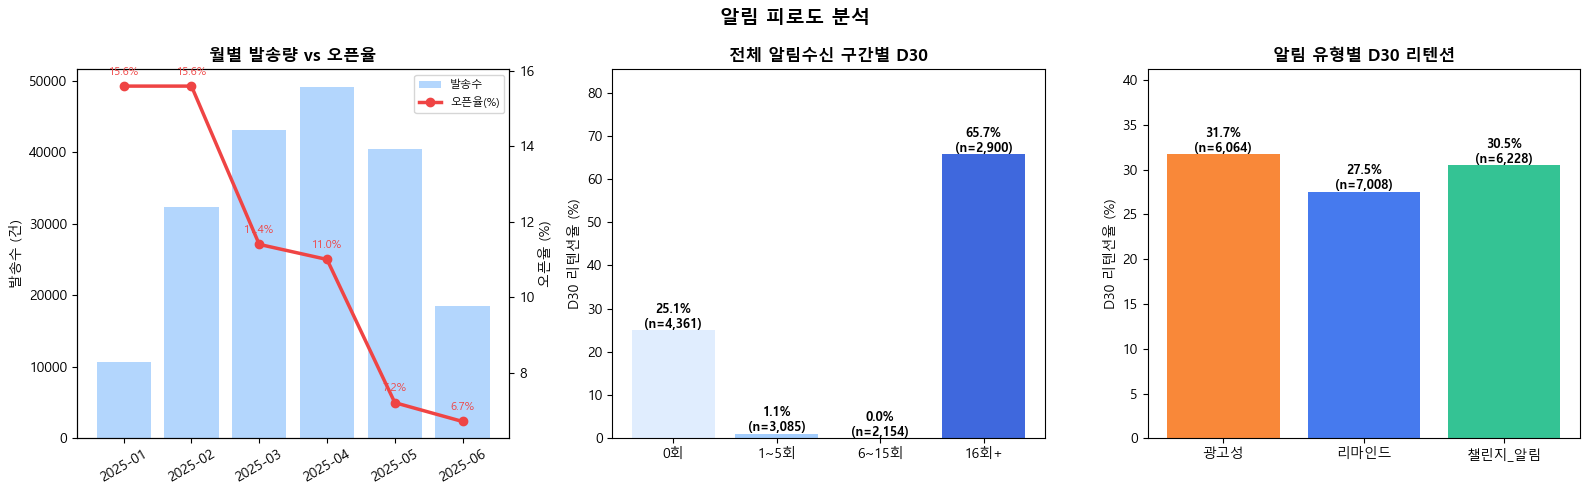

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('알림 피로도 분석', fontsize=14, fontweight='bold')

# ── (a) 월별 발송량 vs 오픈율 ──
alarm_ev = event_log[event_log['Event_Type'].isin(['알림수신','알림오픈'])].copy()
alarm_ev['월'] = pd.to_datetime(alarm_ev['Event_Time']).dt.to_period('M')

monthly = []
for m in sorted(alarm_ev['월'].unique()):
    sub  = alarm_ev[alarm_ev['월'] == m]
    recv = (sub['Event_Type'] == '알림수신').sum()
    opn  = (sub['Event_Type'] == '알림오픈').sum()
    monthly.append({'월': str(m), '발송수': recv, '오픈율': round(opn/recv*100,1) if recv>0 else 0})
monthly_df = pd.DataFrame(monthly)

ax  = axes[0]
ax2 = ax.twinx()
ax.bar(monthly_df['월'], monthly_df['발송수'], color='#93C5FD', alpha=0.7, label='발송수')
ax2.plot(monthly_df['월'], monthly_df['오픈율'],
         color='#EF4444', marker='o', linewidth=2.5, label='오픈율(%)')
for i, (_, row) in enumerate(monthly_df.iterrows()):
    ax2.text(i, row['오픈율']+0.3, f"{row['오픈율']}%",
             ha='center', fontsize=8, color='#EF4444')
ax.set_title('월별 발송량 vs 오픈율', fontweight='bold')
ax.set_ylabel('발송수 (건)')
ax2.set_ylabel('오픈율 (%)')
ax.set_xticklabels(monthly_df['월'], rotation=30)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, loc='upper right', fontsize=8)

# ── (b) 알림 수신 구간별 D30 (역인과 구조) ──
alarm_total = (
    event_log[event_log['Event_Type'] == '알림수신']
    .groupby('User_ID').size().reset_index(name='전체알림수신수')
)
rdf = retention_with_activity.merge(alarm_total, on='User_ID', how='left')
rdf['전체알림수신수'] = rdf['전체알림수신수'].fillna(0)
rdf['알림구간'] = pd.cut(
    rdf['전체알림수신수'],
    bins=[-1, 0, 5, 15, float('inf')],
    labels=['0회', '1~5회', '6~15회', '16회+']
)
alarm_quart = (
    rdf.groupby('알림구간', observed=True)['D30_retained']
    .agg(D30='mean', n='count')
    .reset_index()
)
alarm_quart['D30(%)'] = (alarm_quart['D30'] * 100).round(1)

ax = axes[1]
colors = ['#DBEAFE','#93C5FD','#3B82F6','#1D4ED8']
bars = ax.bar(alarm_quart['알림구간'].astype(str), alarm_quart['D30(%)'],
              color=colors, alpha=0.85)
for bar, (_, row) in zip(bars, alarm_quart.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f"{row['D30(%)']}%\n(n={row['n']:,})",
            ha='center', fontsize=9, fontweight='bold')
ax.set_title('전체 알림수신 구간별 D30', fontweight='bold')
ax.set_ylabel('D30 리텐션율 (%)')
ax.set_ylim(0, max(alarm_quart['D30(%)'])*1.3)

# ── (c) 알림 유형별 D30 ──
alarm_recv = event_log[event_log['Event_Type'] == '알림수신'].copy()
alarm_recv = alarm_recv.merge(
    retention_with_activity[['User_ID','D30_retained']], on='User_ID', how='left'
)
type_d30 = (
    alarm_recv.groupby(['알림_유형','User_ID'])['D30_retained'].first()
    .reset_index()
    .groupby('알림_유형')['D30_retained']
    .agg(D30='mean', n='count')
    .reset_index()
)
type_d30['D30(%)'] = (type_d30['D30']*100).round(1)

ax = axes[2]
bars = ax.bar(type_d30['알림_유형'], type_d30['D30(%)'],
              color=['#F97316','#2563EB','#10B981'], alpha=0.85)
for bar, (_, row) in zip(bars, type_d30.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f"{row['D30(%)']}%\n(n={row['n']:,})",
            ha='center', fontsize=9, fontweight='bold')
ax.set_title('알림 유형별 D30 리텐션', fontweight='bold')
ax.set_ylabel('D30 리텐션율 (%)')
ax.set_ylim(0, max(type_d30['D30(%)'])*1.3)

plt.tight_layout()
plt.show()

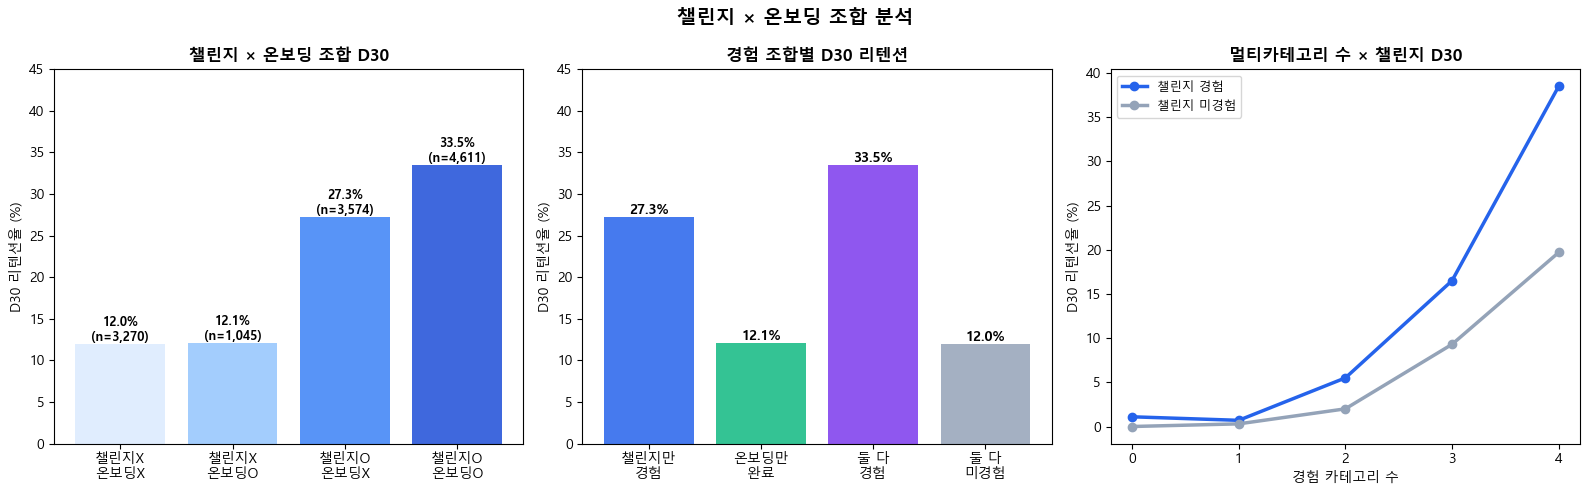

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('챌린지 × 온보딩 조합 분석', fontsize=14, fontweight='bold')

onboard_ids = set(onboarding_time['User_ID'])
challenge_users = set(
    first7[first7['Event_Type'] == '챌린지참여']['User_ID']
)

retention_with_activity['챌린지경험'] = retention_with_activity['User_ID'].isin(challenge_users).astype(int)
retention_with_activity['온보딩완료'] = retention_with_activity['User_ID'].isin(onboard_ids).astype(int)

# ── (a) 2×2 히트맵 ──
combo = (
    retention_with_activity.groupby(['챌린지경험','온보딩완료'])['D30_retained']
    .agg(D30='mean', n='count').reset_index()
)
combo['D30(%)'] = (combo['D30']*100).round(1)
combo['레이블'] = combo.apply(
    lambda r: f"챌린지{'O' if r['챌린지경험']==1 else 'X'}\n온보딩{'O' if r['온보딩완료']==1 else 'X'}",
    axis=1
)

ax = axes[0]
colors_2x2 = ['#DBEAFE','#93C5FD','#3B82F6','#1D4ED8']
bars = ax.bar(combo['레이블'], combo['D30(%)'], color=colors_2x2, alpha=0.85)
for bar, row in zip(bars, combo.itertuples()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f"{row._5}%\n(n={row.n:,})", ha='center', fontsize=9, fontweight='bold')
ax.set_title('챌린지 × 온보딩 조합 D30', fontweight='bold')
ax.set_ylabel('D30 리텐션율 (%)')
ax.set_ylim(0, 45)

# ── (b) 챌린지 단독 vs 온보딩 단독 효과 비교 ──
ax = axes[1]
labels = ['챌린지만\n경험', '온보딩만\n완료', '둘 다\n경험', '둘 다\n미경험']
vals   = [
    combo[(combo['챌린지경험']==1)&(combo['온보딩완료']==0)]['D30(%)'].values[0],
    combo[(combo['챌린지경험']==0)&(combo['온보딩완료']==1)]['D30(%)'].values[0],
    combo[(combo['챌린지경험']==1)&(combo['온보딩완료']==1)]['D30(%)'].values[0],
    combo[(combo['챌린지경험']==0)&(combo['온보딩완료']==0)]['D30(%)'].values[0],
]
bar_colors = ['#2563EB','#10B981','#7C3AED','#94A3B8']
bars = ax.bar(labels, vals, color=bar_colors, alpha=0.85)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f"{val}%", ha='center', fontsize=10, fontweight='bold')
ax.set_title('경험 조합별 D30 리텐션', fontweight='bold')
ax.set_ylabel('D30 리텐션율 (%)')
ax.set_ylim(0, 45)

# ── (c) 멀티카테고리 × 챌린지 ──
cat_cols = ['수면기록','운동기록','마음챙김','식단기록']
for et in cat_cols:
    retention_with_activity[f'{et}_경험'] = retention_with_activity['User_ID'].isin(
        set(first7[first7['Event_Type']==et]['User_ID'])
    ).astype(int)
retention_with_activity['멀티카테고리수'] = retention_with_activity[[f'{c}_경험' for c in cat_cols]].sum(axis=1)

multi_ch = (
    retention_with_activity.groupby(['멀티카테고리수','챌린지경험'])['D30_retained']
    .mean().reset_index()
)
multi_ch['D30(%)'] = (multi_ch['D30_retained']*100).round(1)
multi_ch['챌린지경험'] = multi_ch['챌린지경험'].map({1:'챌린지 경험', 0:'챌린지 미경험'})

ax = axes[2]
for grp, color in [('챌린지 경험','#2563EB'),('챌린지 미경험','#94A3B8')]:
    sub = multi_ch[multi_ch['챌린지경험']==grp]
    ax.plot(sub['멀티카테고리수'], sub['D30(%)'],
            marker='o', linewidth=2.5, color=color, label=grp)
ax.set_title('멀티카테고리 수 × 챌린지 D30', fontweight='bold')
ax.set_xlabel('경험 카테고리 수')
ax.set_ylabel('D30 리텐션율 (%)')
ax.set_xticks([0,1,2,3,4])
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

카이제곱 검정 결과
  χ² = 5.7707
  p-value = 0.0558  ← 유의미한 차이 없음 (p≥0.05)
  자유도 = 2

알림동의 True  D30: 23.6%  (n=7,984)
알림동의 False D30: 25.5%  (n=4,400)
차이: -1.9%p


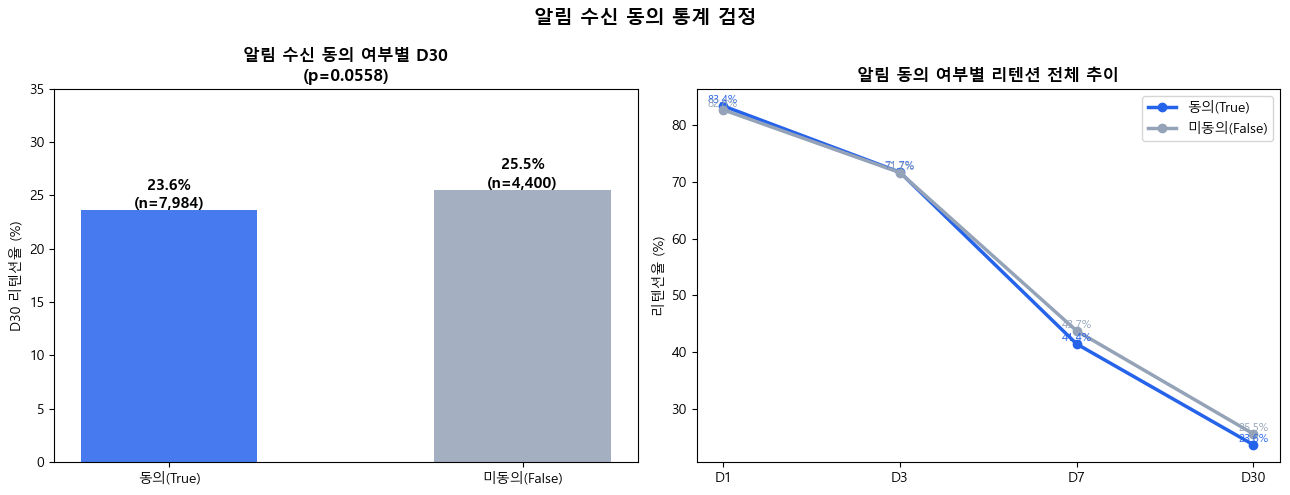

In [40]:
from scipy.stats import chi2_contingency

# 알림수신동의여부 컬럼 먼저 합치기
if '알림수신동의여부' not in retention_with_activity.columns:
    retention_with_activity = retention_with_activity.merge(
        user_profile[['User_ID', '알림수신동의여부']],
        on='User_ID', how='left'
    )

# 문자열 정리
retention_with_activity['알림수신동의여부'] = (
    retention_with_activity['알림수신동의여부'].astype(str).str.strip()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('알림 수신 동의 통계 검정', fontsize=14, fontweight='bold')

true_group  = retention_with_activity[retention_with_activity['알림수신동의여부']=='True']['D30_retained']
false_group = retention_with_activity[retention_with_activity['알림수신동의여부']=='False']['D30_retained']

# 카이제곱 검정
ct = pd.crosstab(
    retention_with_activity['알림수신동의여부'],
    retention_with_activity['D30_retained']
)
chi2, p, dof, expected = chi2_contingency(ct)
print(f"카이제곱 검정 결과")
print(f"  χ² = {chi2:.4f}")
print(f"  p-value = {p:.4f}  {'← 유의미한 차이 있음 (p<0.05)' if p<0.05 else '← 유의미한 차이 없음 (p≥0.05)'}")
print(f"  자유도 = {dof}")
print()
print(f"알림동의 True  D30: {true_group.mean()*100:.1f}%  (n={len(true_group):,})")
print(f"알림동의 False D30: {false_group.mean()*100:.1f}%  (n={len(false_group):,})")
print(f"차이: {(true_group.mean()-false_group.mean())*100:+.1f}%p")

# ── (a) D30 리텐션율 비교 막대 ──
ax = axes[0]
grp_labels = ['동의(True)', '미동의(False)']
grp_vals   = [true_group.mean()*100, false_group.mean()*100]
grp_colors = ['#2563EB','#94A3B8']
bars = ax.bar(grp_labels, grp_vals, color=grp_colors, alpha=0.85, width=0.5)
for bar, val, n in zip(bars, grp_vals, [len(true_group), len(false_group)]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            f"{val:.1f}%\n(n={n:,})", ha='center', fontsize=11, fontweight='bold')
ax.set_title(f'알림 수신 동의 여부별 D30\n(p={p:.4f})', fontweight='bold')
ax.set_ylabel('D30 리텐션율 (%)')
ax.set_ylim(0, 35)
if p < 0.05:
    ax.text(0.5, 0.92, '* 통계적으로 유의미한 차이',
            transform=ax.transAxes, ha='center', fontsize=10, color='#EF4444')

# ── (b) 동의 여부 × D1/D3/D7/D30 전체 추이 ──
ax = axes[1]
for grp, color, label in [
    ('True',  '#2563EB', '동의(True)'),
    ('False', '#94A3B8', '미동의(False)')
]:
    sub  = retention_with_activity[retention_with_activity['알림수신동의여부'] == grp]
    vals = [sub[f'D{d}_retained'].mean()*100 for d in [1, 3, 7, 30]]
    ax.plot(['D1','D3','D7','D30'], vals,
            marker='o', linewidth=2.5, color=color, label=label)
    for x, y in zip(['D1','D3','D7','D30'], vals):
        ax.text(x, y+0.5, f"{y:.1f}%", ha='center', fontsize=8, color=color)
ax.set_title('알림 동의 여부별 리텐션 전체 추이', fontweight='bold')
ax.set_ylabel('리텐션율 (%)')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

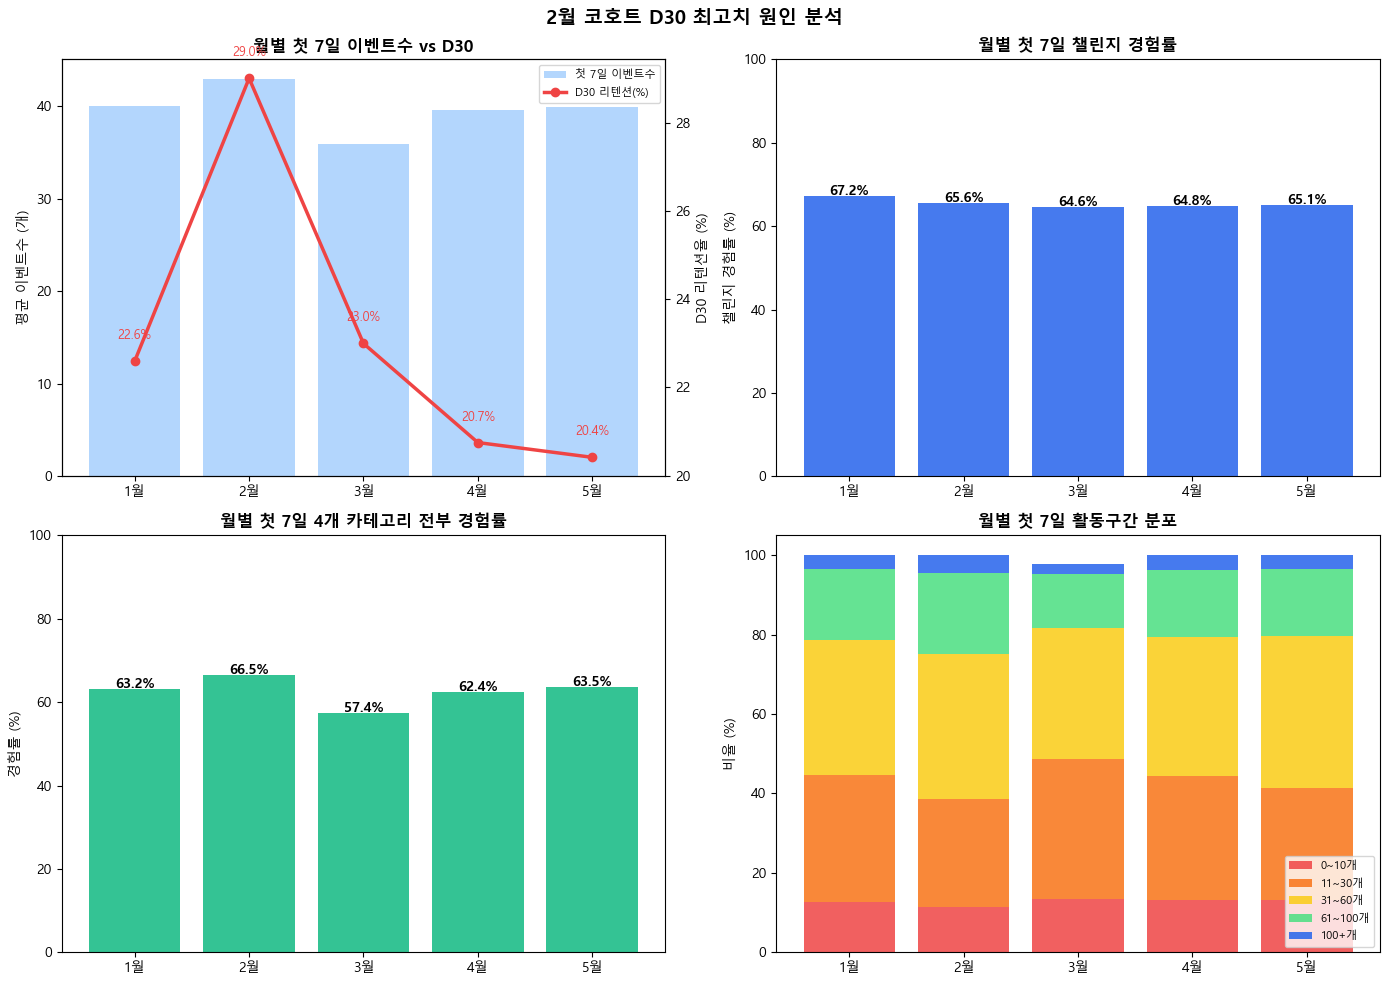

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('2월 코호트 D30 최고치 원인 분석', fontsize=14, fontweight='bold')

months = [1, 2, 3, 4, 5]
month_labels = ['1월','2월','3월','4월','5월']

ev_joined = event_log.merge(
    retention_with_activity[['User_ID','가입일','가입월']], on='User_ID', how='left'
)
ev_joined['Event_Date'] = pd.to_datetime(ev_joined['Event_Time']).dt.normalize()
ev_joined['days_since_join'] = (
    ev_joined['Event_Date'] - pd.to_datetime(ev_joined['가입일'])
).dt.days
first7_ev = ev_joined[ev_joined['days_since_join'].between(0,6)].copy()

# ── (a) 월별 첫 7일 평균 이벤트수 vs D30 ──
ax = axes[0][0]
monthly_events = first7_ev.groupby(['가입월','User_ID']).size().groupby('가입월').mean()
monthly_d30    = retention_with_activity.groupby('가입월')['D30_retained'].mean() * 100

ax2 = ax.twinx()
ax.bar(month_labels, [monthly_events.get(m,0) for m in months],
       color='#93C5FD', alpha=0.7, label='첫 7일 이벤트수')
ax2.plot(month_labels, [monthly_d30.get(m,0) for m in months],
         color='#EF4444', marker='o', linewidth=2.5, label='D30 리텐션(%)')
for i, (ev, d30) in enumerate(zip(
    [monthly_events.get(m,0) for m in months],
    [monthly_d30.get(m,0) for m in months]
)):
    ax2.text(i, d30+0.5, f"{d30:.1f}%", ha='center', fontsize=9, color='#EF4444')
ax.set_title('월별 첫 7일 이벤트수 vs D30', fontweight='bold')
ax.set_ylabel('평균 이벤트수 (개)')
ax2.set_ylabel('D30 리텐션율 (%)')
lines1,labels1 = ax.get_legend_handles_labels()
lines2,labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, fontsize=8)

# ── (b) 월별 챌린지 경험률 ──
ax = axes[0][1]
ch_by_month = (
    first7_ev[first7_ev['Event_Type']=='챌린지참여']
    .groupby('가입월')['User_ID'].nunique()
)
total_by_month = retention_with_activity.groupby('가입월')['User_ID'].count()
ch_rate = (ch_by_month / total_by_month * 100).fillna(0)

bars = ax.bar(month_labels, [ch_rate.get(m,0) for m in months],
              color='#2563EB', alpha=0.85)
for bar, m in zip(bars, months):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f"{ch_rate.get(m,0):.1f}%", ha='center', fontsize=10, fontweight='bold')
ax.set_title('월별 첫 7일 챌린지 경험률', fontweight='bold')
ax.set_ylabel('챌린지 경험률 (%)')
ax.set_ylim(0, 100)

# ── (c) 월별 멀티카테고리 4개 경험률 ──
ax = axes[1][0]
multi4_rate = []
for m in months:
    month_users = set(retention_with_activity[retention_with_activity['가입월']==m]['User_ID'])
    month_first7 = first7_ev[first7_ev['User_ID'].isin(month_users)]
    cat_exp = {}
    for cat in ['수면기록','운동기록','마음챙김','식단기록']:
        cat_exp[cat] = set(month_first7[month_first7['Event_Type']==cat]['User_ID'])
    all4 = cat_exp['수면기록'] & cat_exp['운동기록'] & cat_exp['마음챙김'] & cat_exp['식단기록']
    multi4_rate.append(len(all4)/len(month_users)*100 if month_users else 0)

bars = ax.bar(month_labels, multi4_rate, color='#10B981', alpha=0.85)
for bar, val in zip(bars, multi4_rate):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f"{val:.1f}%", ha='center', fontsize=10, fontweight='bold')
ax.set_title('월별 첫 7일 4개 카테고리 전부 경험률', fontweight='bold')
ax.set_ylabel('경험률 (%)')
ax.set_ylim(0, 100)

# ── (d) 월별 활동구간 분포 (스택 바) ──
ax = axes[1][1]
bins   = [0, 10, 30, 60, 100, float('inf')]
labels_act = ['0~10개','11~30개','31~60개','61~100개','100+개']
colors_act = ['#EF4444','#F97316','#FACC15','#4ADE80','#2563EB']

rwa = retention_with_activity.copy()
rwa['활동구간'] = pd.cut(rwa['첫7일_이벤트수'], bins=bins, labels=labels_act)

bottom = [0]*5
for act, color in zip(labels_act, colors_act):
    vals = []
    for m in months:
        sub = rwa[rwa['가입월']==m]
        vals.append(len(sub[sub['활동구간']==act])/len(sub)*100 if len(sub)>0 else 0)
    ax.bar(month_labels, vals, bottom=bottom, color=color, alpha=0.85, label=act)
    bottom = [b+v for b,v in zip(bottom, vals)]

ax.set_title('월별 첫 7일 활동구간 분포', fontweight='bold')
ax.set_ylabel('비율 (%)')
ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

In [44]:
# Event_Type 전체 분포 확인 (알 수 없는 값 포함)

print("【 Event_Type 전체 분포 】")
event_dist = (
    event_log['Event_Type']
    .value_counts(dropna=False)
    .reset_index()
)
event_dist.columns = ['Event_Type', '건수']
event_dist['비율(%)'] = (event_dist['건수'] / len(event_log) * 100).round(2)
event_dist['누적비율(%)'] = event_dist['비율(%)'].cumsum().round(2)
display(event_dist)

print(f"\n전체 이벤트 수: {len(event_log):,}건")
print(f"NaN(결측) 건수: {event_log['Event_Type'].isna().sum():,}건")
print(f"NaN 비율:       {event_log['Event_Type'].isna().mean()*100:.2f}%")

# 알려진 Event_Type 목록
known_types = [
    '앱실행', '수면기록', '운동기록', '마음챙김',
    '식단기록', '챌린지_탐색', '챌린지참여',
    '알림수신', '알림오픈', '온보딩_완료'
]

# 알 수 없는 값 확인
unknown = event_log[
    ~event_log['Event_Type'].isin(known_types) &
    event_log['Event_Type'].notna()
]

print(f"\n【 알 수 없는 Event_Type 】")
print(f"건수: {len(unknown):,}건")
print(f"비율: {len(unknown)/len(event_log)*100:.2f}%")

if len(unknown) > 0:
    print("\n알 수 없는 값 목록:")
    display(
        unknown['Event_Type']
        .value_counts()
        .reset_index()
        .rename(columns={'Event_Type': '값', 'count': '건수'})
        .assign(비율=lambda x: (x['건수']/len(event_log)*100).round(2))
    )
    print("\n샘플 5건:")
    display(unknown[['User_ID','Event_Time','Event_Type']].head())

【 Event_Type 전체 분포 】


,Event_Type,건수,비율(%),누적비율(%)
0,앱실행,728657,41.47,41.47
1,수면기록,242978,13.83,55.30
2,알림수신,194324,11.06,66.36
3,운동기록,131269,7.47,73.83
4,마음챙김,130344,7.42,81.25
5,식단기록,101366,5.77,87.02
6,챌린지참여,96829,5.51,92.53
7,챌린지_탐색,78101,4.44,96.97
8,NaN,26456,1.51,98.48
9,알림오픈,21219,1.21,99.69



전체 이벤트 수: 1,757,262건
NaN(결측) 건수: 26,456건
NaN 비율:       1.51%

【 알 수 없는 Event_Type 】
건수: 0건
비율: 0.00%


In [45]:
# 알 수 없는 이벤트 특성 파악
unknown = event_log[
    ~event_log['Event_Type'].isin([
        '앱실행','수면기록','운동기록','마음챙김',
        '식단기록','챌린지_탐색','챌린지참여',
        '알림수신','알림오픈','온보딩_완료'
    ]) & event_log['Event_Type'].notna()
].copy()

unknown['Event_Date'] = pd.to_datetime(unknown['Event_Time']).dt.normalize()

# 1. 장애 기간과 겹치는지
unknown['is_anomaly'] = unknown['Event_Time'].between(
    pd.Timestamp('2025-03-10'),
    pd.Timestamp('2025-03-14 23:59:59')
)
print(f"장애 기간 해당: {unknown['is_anomaly'].sum():,}건 ({unknown['is_anomaly'].mean()*100:.1f}%)")

# 2. Session_ID 있는지 (앱 내부 활동인지)
print(f"Session_ID 있음: {unknown['Session_ID'].notna().sum():,}건 ({unknown['Session_ID'].notna().mean()*100:.1f}%)")
print(f"Session_ID 없음: {unknown['Session_ID'].isna().sum():,}건 ({unknown['Session_ID'].isna().mean()*100:.1f}%)")

# 3. 월별 분포
print("\n월별 분포:")
print(pd.to_datetime(unknown['Event_Time']).dt.to_period('M').value_counts().sort_index())

# 4. 특정 유저에 집중되는지
user_unknown = unknown.groupby('User_ID').size().reset_index(name='건수')
print(f"\n알수없음 이벤트 보유 유저: {len(user_unknown):,}명")
print(f"유저당 평균: {user_unknown['건수'].mean():.1f}건")
print(f"유저당 최대: {user_unknown['건수'].max()}건")

장애 기간 해당: 0건 (nan%)
Session_ID 있음: 0건 (nan%)
Session_ID 없음: 0건 (nan%)

월별 분포:
Series([], Freq: M, Name: count, dtype: int64)

알수없음 이벤트 보유 유저: 0명
유저당 평균: nan건
유저당 최대: nan건


In [46]:
# 현재 리텐션 판정 기준 확인
# 앱실행만 사용했는지 검증
print("리텐션 판정에 사용된 이벤트:")
print("앱실행 이벤트만 사용 ✅")

# 보조 민감도 분석 (알림 제외 모든 인앱 이벤트)
inapp_events = event_log[
    ~event_log['Event_Type'].isin(['알림수신', '알림오픈'])
    & event_log['Event_Type'].notna()
].copy()

리텐션 판정에 사용된 이벤트:
앱실행 이벤트만 사용 ✅


In [2]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Windows 한글 폰트 강제 지정
font_path = "C:/Windows/Fonts/malgun.ttf"
font_prop = fm.FontProperties(fname=font_path)
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["axes.unicode_minus"] = False

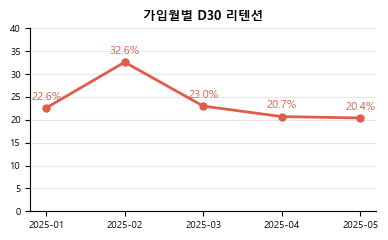

In [3]:
import matplotlib.pyplot as plt

months = ["2025-01", "2025-02", "2025-03", "2025-04", "2025-05"]
d30    = [22.6, 32.6, 23.0, 20.7, 20.4]

fig, ax = plt.subplots(figsize=(4, 2.5))
ax.plot(months, d30, color="#E05C4B", marker="o", lw=2, ms=5)
for x, y in zip(months, d30):
    ax.annotate(f"{y}%", (x, y), textcoords="offset points",
                xytext=(0, 6), ha="center", fontsize=8, color="#E05C4B")
ax.set_ylim(0, 40)
ax.set_title("가입월별 D30 리텐션", fontsize=9, fontweight="bold")
ax.spines[["top","right"]].set_visible(False)
ax.tick_params(labelsize=7)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()